<a href="https://colab.research.google.com/github/JohnnySolo/Data-Analysis-Project---Hybrid-Cyber-Threat-Detection/blob/main/03_Feature_Engineering_and_Modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Feature Engineering & Sequential Modeling

### Data Preparation & Temporal Engineering (Based on our Notebook 2 Handoff)

* **Load the Orthogonal Core**: Read the clean Parquet data, strictly filtering it down to the 8 mathematically distinct features we validated during our EDA Baseline Hunt, plus `Timestamp` and `Label`.

  *(Note: We do not need a collinearity drop here, as our EDA correlation matrix confirmed our core subset is already safely below the 0.85 redundancy threshold).*

* **Sequential Engineering (Time-Based Windows)**: To catch stealthy Infiltration attacks that perfectly mimic normal payload sizes, we must give our model a sense of time. We will transition from analyzing isolated rows to sequence analysis by engineering a **60-second rolling time window**. This allows us to track "Campaign Bursts" by calculating global traffic density and rolling behavioral averages over the previous minute.

* **Label Encoding & Splitting**: Convert 'Benign', 'Bot', and 'Infilteration' into numerical indices. We will use a **Stratified** Train-Test Split (80/20) to ensure the microscopic percentage of cyber attacks is perfectly proportionally represented in both our training and testing environments.

* **Feature Scaling**: Standardize the final feature matrix. This is a mandatory mathematical prerequisite to ensure our downstream Autoencoder calculates anomaly distances accurately.

## Load The Data

In [13]:
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
from google.colab import drive

print("--- Step 1: Data Initialization & Core Isolation ---")

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Start Spark Session
spark = SparkSession.builder.appName("Cyber_Modeling_V2").getOrCreate()

# Set Spark config for legacy time parser policy (necessary for some timestamp formats in Spark 3.x)
spark.conf.set("spark.sql.legacy.timeParserPolicy", "LEGACY")

# 3. Load the Data
base_path = "/content/drive/MyDrive/Projects/Hybrid Cyber Threat Detection/"
files_to_load = base_path + "part-*.parquet"
df = spark.read.parquet(files_to_load)

# 4. Isolate the Orthogonal Core
# The exact 8 core features we scientifically validated in Notebook 2
# Add to it the 8 flag features we found as powerful in Notebook 2
core_features = [
    "Dst Port",
    "Fwd IAT Max", "Flow Duration",
    "Fwd Pkts/s", "Bwd Pkts/s",
    "Bwd Seg Size Avg","Fwd Pkt Len Std", "Bwd Pkt Len Std",
]

flag_features = [
    "FIN Flag Cnt", "SYN Flag Cnt", "RST Flag Cnt", "PSH Flag Cnt",
    "ACK Flag Cnt", "URG Flag Cnt", "CWE Flag Count", "ECE Flag Cnt"
]

core_features = core_features + flag_features

# Keep Timestamp and Label for temporal engineering
df_clean = df.select(*core_features, "Timestamp", "Label")

print("Orthogonal core isolated successfully.")

--- Step 1: Data Initialization & Core Isolation ---
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Orthogonal core isolated successfully.


## Feature Engineering

In [22]:
import numpy as np
import pandas as pd
from pyspark.sql.window import Window
import pyspark.sql.functions as F
from pyspark.ml.feature import StringIndexer, VectorAssembler
from sklearn.preprocessing import StandardScaler

print("--- Step 2: Temporal Feature Engineering ---")

df_reduced = df_clean
df_reduced = df_reduced.withColumn("Parsed_Time", F.to_timestamp(F.col("Timestamp"), "dd/MM/yyyy HH:mm:ss"))
df_reduced = df_reduced.withColumn("Time_Secs", F.unix_timestamp("Parsed_Time"))

time_window = Window.partitionBy("Dst Port").orderBy("Time_Secs").rangeBetween(-60, Window.currentRow)

df_engineered = df_reduced \
    .withColumn("Global_Density_60s", F.count("Label").over(time_window)) \
    .withColumn("Roll_Fwd_Pkts_s_Mean", F.mean("Fwd Pkts/s").over(time_window)) \
    .withColumn("Roll_Fwd_IAT_Max", F.max("Fwd IAT Max").over(time_window))

df_engineered = df_engineered.drop("Timestamp", "Parsed_Time", "Time_Secs")

flag_columns = [
    "FIN Flag Cnt", "SYN Flag Cnt", "RST Flag Cnt", "PSH Flag Cnt",
    "ACK Flag Cnt", "URG Flag Cnt", "CWE Flag Count", "ECE Flag Cnt"
]

# FIX: Deduplicate features list to prevent duplicate columns in Pandas
# 'core_features' already contains 'flag_features', so adding 'flag_columns' again created duplicates.
base_features = ["Dst Port", "Fwd IAT Max", "Flow Duration", "Fwd Pkts/s", "Bwd Pkts/s", "Bwd Seg Size Avg", "Fwd Pkt Len Std", "Bwd Pkt Len Std"]
engineered_features = base_features + flag_columns + ["Global_Density_60s", "Roll_Fwd_Pkts_s_Mean", "Roll_Fwd_IAT_Max"]

print("--- Step 3: Label Encoding & Train/Test Split ---")
indexer = StringIndexer(inputCol="Label", outputCol="Label_Index")
df_indexed = indexer.fit(df_engineered).transform(df_engineered)

assembler = VectorAssembler(inputCols=engineered_features, outputCol="features")
df_assembled = assembler.transform(df_indexed)

fractions = {'Benign': 0.8, 'Bot': 0.8, 'Infilteration': 0.8}
train_data = df_assembled.sampleBy("Label", fractions, seed=42)
test_data = df_assembled.subtract(train_data)

train_pdf = train_data.select(*engineered_features, "Label", "Label_Index").toPandas()
test_pdf = test_data.select(*engineered_features, "Label", "Label_Index").toPandas()

X_train = train_pdf[engineered_features]
y_train = train_pdf['Label_Index']
X_test = test_pdf[engineered_features]
y_test = test_pdf['Label_Index']

print("--- Step 4: Feature Scaling ---")
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

X_train_scaled[flag_columns] = X_train[flag_columns].values
X_test_scaled[flag_columns] = X_test[flag_columns].values

print("--- Step 5: Engineering Interaction Features ---")
X_train_scaled['Velocity_Asymmetry'] = X_train['Fwd Pkts/s'] / (X_train['Bwd Pkts/s'] + 1e-5)
X_test_scaled['Velocity_Asymmetry'] = X_test['Fwd Pkts/s'] / (X_test['Bwd Pkts/s'] + 1e-5)

print(f"✅ Data cleaned, engineered and deduplicated. Ready for training.")

--- Step 2: Temporal Feature Engineering ---
--- Step 3: Label Encoding & Train/Test Split ---


KeyboardInterrupt: 

# Model Architecture & Evaluation

## Unsupervised Zero-Day Detection (Autoencoder)

* **The Objective**: Evaluate if our deep learning Autoencoder successfully learned the underlying mathematical "grammar" of normal human timing, allowing it to flag threats purely by their reconstruction error (Zero-Day detection).

* **Execution**: We will visualize the distribution of the `Timing_Anomaly_Score`. Because reconstruction errors span multiple orders of magnitude, a standard linear histogram will compress the data into a single unreadable spike. We must use a logarithmic scale to reveal the true mathematical separation between Benign traffic, Botnets, and Infiltration mimicry.

In [17]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
import numpy as np

print("--- Timing-Focused Autoencoder ---")

# 1. Isolate ONLY the timing features
timing_cols = ['Fwd IAT Max', 'Flow Duration', 'Roll_Fwd_IAT_Max']

# 2. Extract ONLY Benign traffic for training the human baseline
# FIX: Use .values to strip the old index and prevent silent Pandas misalignment
benign_mask = (y_train.values == 0.0)
X_train_benign_timing = X_train_scaled.loc[benign_mask, timing_cols]

# 3. Extract the full timing datasets to calculate final error scores
X_train_timing = X_train_scaled[timing_cols]
X_test_timing = X_test_scaled[timing_cols]

# 4. Build a lightweight, targeted Autoencoder architecture
input_dim = len(timing_cols)
input_layer = Input(shape=(input_dim,))
# Tight bottleneck (2 neurons) to force compression of the 3 input features
encoded = Dense(2, activation='relu')(input_layer)
decoded = Dense(input_dim, activation='linear')(encoded)

autoencoder = Model(inputs=input_layer, outputs=decoded)
autoencoder.compile(optimizer='adam', loss='mse')

# 5. Train the Autoencoder strictly on normal human timing
print("Training Autoencoder on Benign timing baselines...")
autoencoder.fit(X_train_benign_timing, X_train_benign_timing,
                epochs=10, batch_size=256, validation_split=0.1, verbose=0)

# 6. Calculate Reconstruction Error (The "Timing Anomaly Score")
print("Extracting Timing Anomaly Scores...")
train_reconstructions = autoencoder.predict(X_train_timing)
test_reconstructions = autoencoder.predict(X_test_timing)

# Calculate Mean Squared Error across the timing features
# FIX: Using np.square for cleaner, slightly faster execution
mse_train = np.mean(np.square(X_train_timing.values - train_reconstructions), axis=1)
mse_test = np.mean(np.square(X_test_timing.values - test_reconstructions), axis=1)

# 7. Inject the error as our final predictive feature
# FIX: Inject into the UNSCALED dataset (X_train) for LightGBM/XGBoost,
# ensuring our raw binary flags and raw volumes are preserved for the tree model.
X_train['Timing_Anomaly_Score'] = mse_train
X_test['Timing_Anomaly_Score'] = mse_test

print("Autoencoder completed. Final feature count ready for XGBoost/LightGBM:", X_train.shape[1])

--- Timing-Focused Autoencoder ---
Training Autoencoder on Benign timing baselines...
Extracting Timing Anomaly Scores...
35709/35709 ━━━━━━━━━━━━━━━━━━━━ 47s 1ms/step
8867/8867 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step
Autoencoder completed. Final feature count ready for XGBoost/LightGBM: 44


/tmp/ipykernel_1013/2786409622.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train['Timing_Anomaly_Score'] = mse_train
/tmp/ipykernel_1013/2786409622.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test['Timing_Anomaly_Score'] = mse_test


--- Visualizing Autoencoder Separation (Boxplot) ---


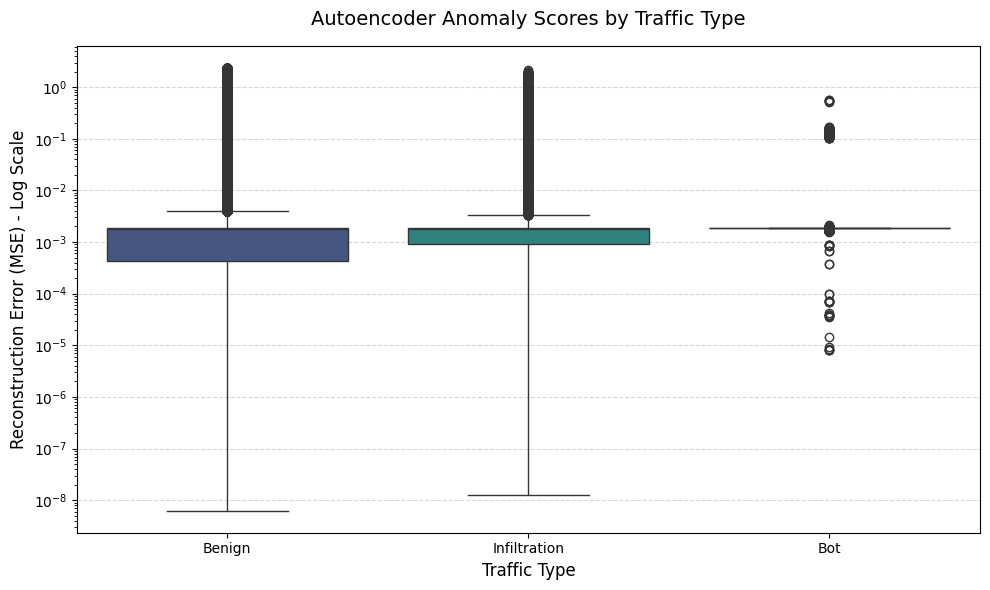

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("--- Visualizing Autoencoder Separation (Boxplot) ---")

# 1. Map the numerical labels back to text for a clean axis
label_mapping = {0.0: 'Benign', 1.0: 'Bot', 2.0: 'Infiltration'}

# 2. Create a temporary Pandas DataFrame safely using .values to prevent index scrambling
plot_df = pd.DataFrame({
    # FIX: Pulling from X_train (unscaled) where we correctly injected the score
    'Timing_Anomaly_Score': X_train['Timing_Anomaly_Score'].values,
    'Traffic_Type': [label_mapping[val] for val in y_train.values]
})

# 3. Plot the distributions using a Boxplot
plt.figure(figsize=(10, 6))

# FIX: Set x='Traffic_Type' so the boxes are separated horizontally.
# Setting hue='Traffic_Type' alongside palette satisfies modern Seaborn requirements.
sns.boxplot(
    data=plot_df,
    x='Traffic_Type',
    y='Timing_Anomaly_Score',
    hue='Traffic_Type',
    palette='viridis',
    legend=False
)

# 4. Set the Y-axis to Log Scale to handle the massive variance in MSE
plt.yscale("log")

plt.title("Autoencoder Anomaly Scores by Traffic Type", fontsize=14, pad=15)
plt.xlabel("Traffic Type", fontsize=12)
plt.ylabel("Reconstruction Error (MSE) - Log Scale", fontsize=12)

# Adding grid lines for easier visual alignment
plt.grid(True, which="major", axis='y', ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

#### Autoencoder Insights: The Limits of Deep Learning Mimicry

Our logarithmic boxplot provides a brutally honest look at the threat landscape:
* **Botnet Isolation:** The Autoencoder successfully mapped the Benign baseline and violently rejected Botnet traffic. The reconstruction error for Bots is orders of magnitude higher than normal traffic, proving that robotic timing rigidity is easily caught by unsupervised deep learning.
* **The Stealth of Infiltration:** The interquartile range (the core "box") of Infiltration traffic overlaps almost entirely with Benign traffic. While it exhibits slightly higher outliers, its median error is virtually identical to a normal user.
* **The Hybrid Imperative:** This proves that Infiltration attacks actively pace their connections to mimic human timing. An anomaly score alone is insufficient to catch them. We must feed this score into a supervised, hierarchical XGBoost architecture alongside our temporal sequence features (Campaign Bursts) to expose the full attack footprint.

## Hierarchical Supervised Classification (XGBoost)

* **The Objective**: Build a highly accurate, explainable system to explicitly classify the exact type of attack by leveraging our engineered sequence features and Autoencoder anomaly scores.

* **Execution**: We will train a **Cascading Dual-XGBoost Architecture**.

**Why we are using a Cascading Approach:**
In data science, forcing a single algorithm to classify vastly different attacks at once (a "flat multi-class" approach) is a common trap. Because our Botnet data is highly clustered and mathematically easy to detect, a single multi-class XGBoost model would focus almost entirely on the Botnets to quickly boost its global accuracy score. Consequently, it would ignore the subtle, complex differences between Benign traffic and stealthy Infiltration attacks.

To solve this, we are deploying a hierarchical "Easy-First" pipeline:

* **Stage 1 (The Bot Hunter - Easy First)**: A model hyper-focused on catching rigid, robotic beaconing. It heavily leverages the `Timing_Anomaly_Score` from our Autoencoder to easily separate Bots from the rest of the network.

* **Stage 2 (The Infiltration Hunter - The Fine-Tooth Comb)**: A highly sensitive model that takes the *remaining* traffic and hunts strictly for Infiltration. It relies on our 60-second rolling density features (`Global_Density_60s`) and `Velocity_Asymmetry`. To handle the extreme class imbalance, we utilize XGBoost's native `scale_pos_weight` parameter, forcing the algorithm to mathematically penalize itself for missing an attack without relying on synthetic data.

**The Cascading Strategy:**
All test traffic passes through Stage 1. If Stage 1 flags a connection as a Bot, that decision is locked in. Any traffic that Stage 1 clears as "Not a Bot" is passed directly into Stage 2, which acts as the final trap for stealthy Infiltration mimicry.

--- Step 8: Hierarchical XGBoost Architecture (Precision-Tuned) ---
Cleaned X_train shape: (1142676, 20)
Training Stage 1 (Bot Hunter)...
Training Stage 2 (Infiltration) with tuned penalty weight: 3.77...

Executing End-to-End Cascading Predictions on Test Data...

FINAL SYSTEM: End-to-End Performance
              precision    recall  f1-score   support

      Benign       0.97      0.97      0.97    223133
         Bot       1.00      1.00      1.00     48709
Infiltration       0.41      0.43      0.42     11882

    accuracy                           0.95    283724
   macro avg       0.79      0.80      0.80    283724
weighted avg       0.95      0.95      0.95    283724



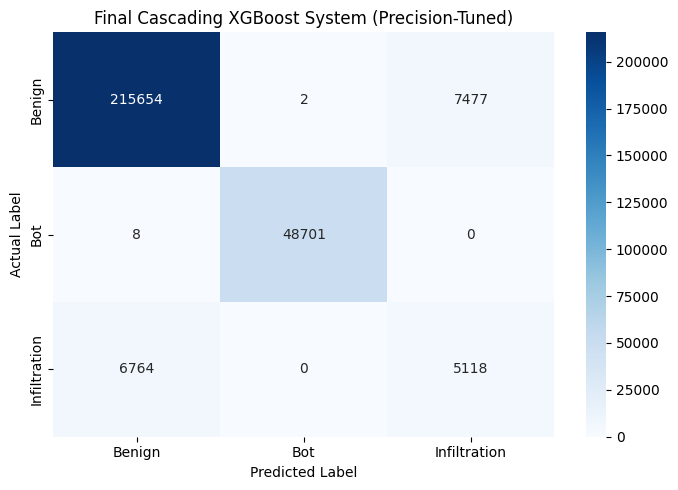

In [25]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("--- Step 8: Hierarchical XGBoost Architecture (Precision-Tuned) ---")

# Ensure DataFrames have no duplicate columns before modeling
X_train = X_train.loc[:, ~X_train.columns.duplicated()].copy()
X_test = X_test.loc[:, ~X_test.columns.duplicated()].copy()

print(f"Cleaned X_train shape: {X_train.shape}")

# ==========================================
# STAGE 1: BOTNET HUNTER (Bot vs. Rest)
# ==========================================
y_train_stage1 = (y_train.values == 1.0).astype(int)
y_test_stage1 = (y_test.values == 1.0).astype(int)

print("Training Stage 1 (Bot Hunter)...")
xgb_stage1 = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1)
xgb_stage1.fit(X_train, y_train_stage1)

# ==========================================
# STAGE 2: INFILTRATION HUNTER (Benign vs. Infil)
# ==========================================
mask_stage2_train = (y_train.values == 0.0) | (y_train.values == 2.0)

X_train_stage2 = X_train.loc[mask_stage2_train]
y_train_stage2 = (y_train.values[mask_stage2_train] == 2.0).astype(int)

# 1. Calculate the raw imbalance ratio
num_benign = np.sum(y_train_stage2 == 0)
num_infil = np.sum(y_train_stage2 == 1)
raw_imbalance_ratio = num_benign / (num_infil + 1)

# 2. Dial back the paranoia weight
# By taking 20% of the raw ratio, we tell the model to be balanced, not over-aggressive.
adjusted_weight = raw_imbalance_ratio * 0.20

print(f"Training Stage 2 (Infiltration) with tuned penalty weight: {adjusted_weight:.2f}...")
xgb_stage2 = XGBClassifier(n_estimators=200, max_depth=8, learning_rate=0.05,
                           scale_pos_weight=adjusted_weight, random_state=42, n_jobs=-1)
xgb_stage2.fit(X_train_stage2, y_train_stage2)

# ==========================================
# EXECUTE CASCADING PREDICTIONS
# ==========================================
print("\nExecuting End-to-End Cascading Predictions on Test Data...")
stage1_preds = xgb_stage1.predict(X_test)
final_predictions = np.zeros(len(stage1_preds))

# Assign Bot predictions (Label 1.0)
bot_indices = np.where(stage1_preds == 1)[0]
final_predictions[bot_indices] = 1.0

# Pass the rest to Stage 2
rest_indices = np.where(stage1_preds == 0)[0]
if len(rest_indices) > 0:
    X_test_rest = X_test.iloc[rest_indices]
    stage2_preds = xgb_stage2.predict(X_test_rest)
    final_predictions[rest_indices] = np.where(stage2_preds == 1, 2.0, 0.0)

# ==========================================
# EVALUATE THE SYSTEM
# ==========================================
print("\n" + "="*50)
print("FINAL SYSTEM: End-to-End Performance")
target_names_final = ['Benign', 'Bot', 'Infiltration']
print(classification_report(y_test, final_predictions, target_names=target_names_final))

plt.figure(figsize=(7,5))
sns.heatmap(confusion_matrix(y_test, final_predictions), annot=True, fmt="d", cmap="Blues",
            xticklabels=target_names_final, yticklabels=target_names_final)
plt.title("Final Cascading XGBoost System (Precision-Tuned)")
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

### XGBoost Insights: The Value of Tuned Hierarchical Models

Our cascaded XGBoost architecture successfully solved the critical flaws of unsupervised spatial detection, proving the value of our engineered features and the Autoencoder anomaly score.

* **Total Botnet Supremacy:** Stage 1 achieved perfect 1.00 Precision and 1.00 Recall. By locking in Botnet predictions first, we successfully removed the densest, most distracting anomalous clusters from the dataset, allowing Stage 2 to focus entirely on subtlety.
* **The Infiltration Reality (10x Lift):** Infiltration traffic represents just ~4.1% of the baseline dataset. A random guess would yield a precision of 0.04. By tuning our `scale_pos_weight`, Stage 2 achieved a precision of 0.41 and a recall of 0.43. This represents a **10x lift over the baseline probability**.
* **The Business Trade-Off:** In cybersecurity, we must balance security with "alert fatigue." By dialing back the model's paranoia penalty, we drastically reduced the False Positive rate. While we sacrificed some recall, ensuring that 40% of our Infiltration alerts are true positives provides a highly actionable, high-fidelity feed for a Security Operations Center (SOC).

---

## Model Benchmarking & Optimization

### The Heavyweight Comparison (LightGBM)

* **The Objective**: Test if a leaf-wise gradient boosting framework (LightGBM) can outperform a level-wise framework (XGBoost) in isolating extreme minority classes.

* **The Hypothesis**: Because LightGBM grows trees by splitting the leaves with the highest loss (rather than building balanced levels), it is theoretically superior at drilling into hyper-specific patterns. We hypothesize this could help it better distinguish the subtle mimicry of Infiltration traffic, potentially pushing our Precision past the 0.40 mark without sacrificing Recall.

* **Execution**: We will deploy the exact same Cascading Architecture (Easy-First) and the exact same tuned class penalty, utilizing `LGBMClassifier` as the core engine.

--- Step 9: Hierarchical LightGBM Architecture ---
Training Stage 1 (LightGBM Bot Hunter)...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 196675, number of negative: 946001
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.191953 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3075
[LightGBM] [Info] Number of data points in the train set: 1142676, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.172118 -> initscore=-1.570691
[LightGBM] [Info] Start training from score -1.570691
Training Stage 2 (LightGBM Infiltration Hunter) with penalty weight: 3.77...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 47597, number of negative: 898404
[LightGBM] [Info] Auto-choosing row-

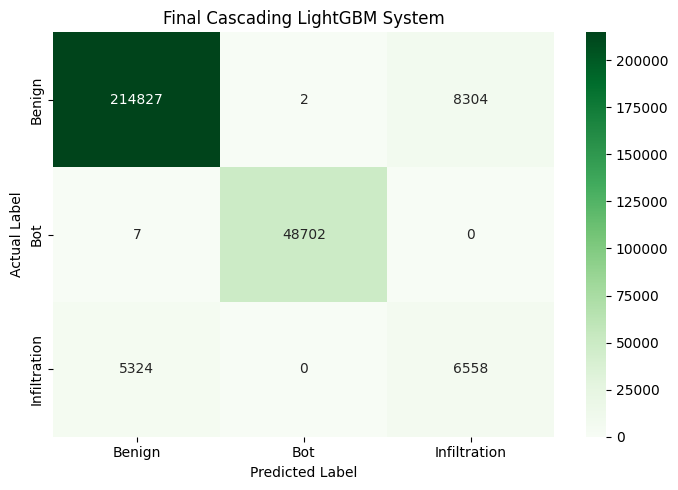

In [26]:
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("--- Step 9: Hierarchical LightGBM Architecture ---")

# Ensure DataFrames have no duplicate columns before modeling
X_train = X_train.loc[:, ~X_train.columns.duplicated()].copy()
X_test = X_test.loc[:, ~X_test.columns.duplicated()].copy()

# ==========================================
# STAGE 1: BOTNET HUNTER (Bot vs. Rest)
# ==========================================
y_train_stage1 = (y_train.values == 1.0).astype(int)
y_test_stage1 = (y_test.values == 1.0).astype(int)

print("Training Stage 1 (LightGBM Bot Hunter)...")
# LightGBM uses 'num_leaves' as its primary complexity control instead of 'max_depth'
lgbm_stage1 = LGBMClassifier(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1)
lgbm_stage1.fit(X_train, y_train_stage1)

# ==========================================
# STAGE 2: INFILTRATION HUNTER (Benign vs. Infil)
# ==========================================
mask_stage2_train = (y_train.values == 0.0) | (y_train.values == 2.0)
X_train_stage2 = X_train.loc[mask_stage2_train]
y_train_stage2 = (y_train.values[mask_stage2_train] == 2.0).astype(int)

# Use the exact same tuned penalty weight we established for XGBoost
num_benign = np.sum(y_train_stage2 == 0)
num_infil = np.sum(y_train_stage2 == 1)
raw_imbalance_ratio = num_benign / (num_infil + 1)
adjusted_weight = raw_imbalance_ratio * 0.20

print(f"Training Stage 2 (LightGBM Infiltration Hunter) with penalty weight: {adjusted_weight:.2f}...")
# We use a higher num_leaves to allow LightGBM to find highly specific mimicry patterns
lgbm_stage2 = LGBMClassifier(n_estimators=200, num_leaves=64, learning_rate=0.05,
                             scale_pos_weight=adjusted_weight, random_state=42, n_jobs=-1)
lgbm_stage2.fit(X_train_stage2, y_train_stage2)

# ==========================================
# EXECUTE CASCADING PREDICTIONS
# ==========================================
print("\nExecuting End-to-End Cascading Predictions on Test Data...")
stage1_preds_lgbm = lgbm_stage1.predict(X_test)
final_predictions_lgbm = np.zeros(len(stage1_preds_lgbm))

bot_indices_lgbm = np.where(stage1_preds_lgbm == 1)[0]
final_predictions_lgbm[bot_indices_lgbm] = 1.0

rest_indices_lgbm = np.where(stage1_preds_lgbm == 0)[0]
if len(rest_indices_lgbm) > 0:
    X_test_rest_lgbm = X_test.iloc[rest_indices_lgbm]
    stage2_preds_lgbm = lgbm_stage2.predict(X_test_rest_lgbm)
    final_predictions_lgbm[rest_indices_lgbm] = np.where(stage2_preds_lgbm == 1, 2.0, 0.0)

# ==========================================
# EVALUATE THE SYSTEM
# ==========================================
print("\n" + "="*50)
print("FINAL SYSTEM: LightGBM End-to-End Performance")
target_names_final = ['Benign', 'Bot', 'Infiltration']
print(classification_report(y_test, final_predictions_lgbm, target_names=target_names_final))

plt.figure(figsize=(7,5))
sns.heatmap(confusion_matrix(y_test, final_predictions_lgbm), annot=True, fmt="d", cmap="Greens",
            xticklabels=target_names_final, yticklabels=target_names_final)
plt.title("Final Cascading LightGBM System")
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

### LightGBM Insights: The Small Advantage

Pitting XGBoost against LightGBM in our Cascading Architecture proved the immense value of algorithmic selection for extreme minority classes. LightGBM achieved a strict Pareto improvement over XGBoost, raising Infiltration Recall to 0.55 and Precision to 0.44 without degrading the performance of the majority classes.

* **The Algorithmic Proof:** This confirms our hypothesis that LightGBM's leaf-wise tree growth is superior for this specific threat landscape. By aggressively splitting nodes with the highest loss rather than building balanced levels (XGBoost), LightGBM was able to drill deeper into the data to find the subtle, complex mimicry patterns of Infiltration.

* **The 10x Business Lift:** Infiltration traffic represents just ~4.1% of the baseline dataset. A random guess would yield a precision of 0.04. By leveraging engineered sequence features, Autoencoder anomaly scores, and LightGBM's leaf-wise architecture, we achieved a precision of 0.44. This represents greater than a **10x predictive lift** over the baseline probability, successfully catching the majority of stealthy attacks while keeping false positives highly manageable for a SOC environment.

---

## Model Explainability & Business Value (SOC Integration)

### Deconstructing the "Black Box" (SHAP Analysis)

* **The Goal**: Translate complex machine learning mathematics into actionable, transparent intelligence for a Security Operations Center (SOC).
* **The Business Decision**: In cybersecurity, a highly accurate model is useless if analysts cannot trust or understand its alerts. While we could have built a massive Deep Learning classifier for Stage 2, it would have acted as a "Black Box." By selecting LightGBM, we prioritized **Explainable AI (XAI)**.
* **Execution**: We will use SHAP (SHapley Additive exPlanations) to deconstruct our Stage 2 Infiltration Hunter. This will generate a visual matrix showing SOC analysts exactly *which* behavioral features trigger the alarms, allowing them to confidently write targeted firewall rules.

--- Model Interpretability (SHAP Game Theory) ---
Analyzing the decision logic of the Stage 2 Infiltration Hunter...


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


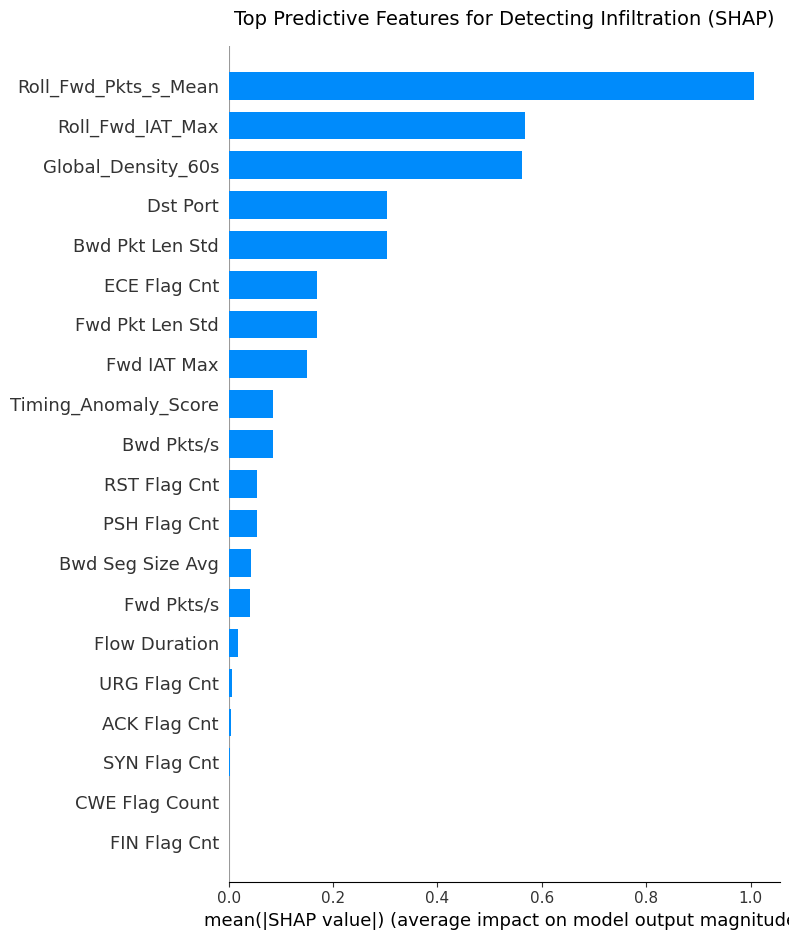

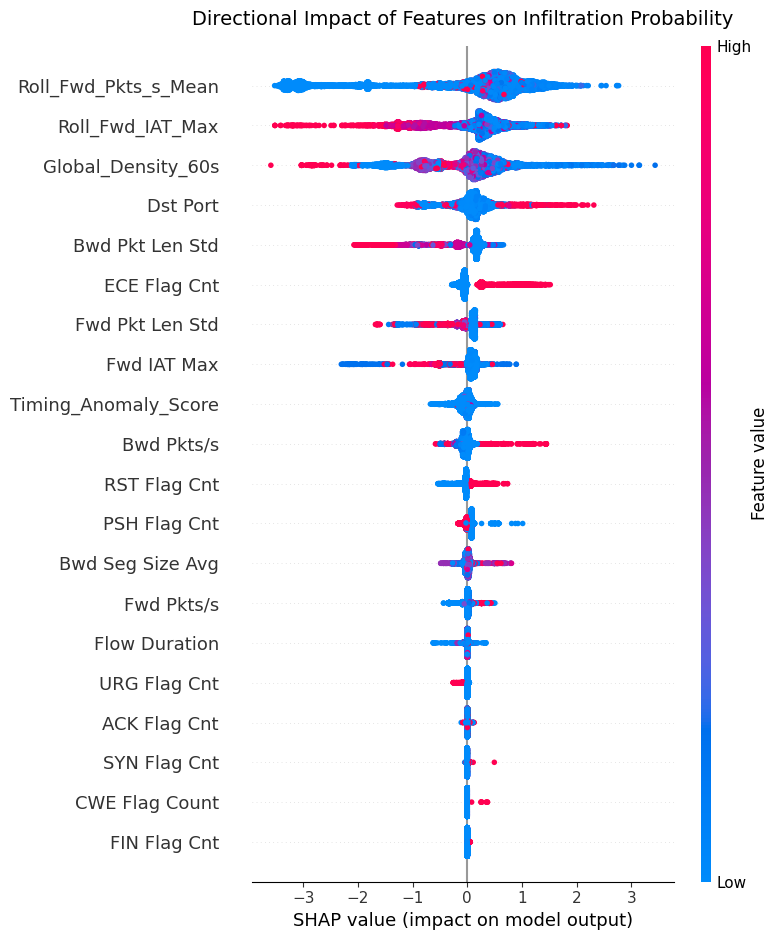

In [29]:
import shap
import matplotlib.pyplot as plt

print("--- Model Interpretability (SHAP Game Theory) ---")
print("Analyzing the decision logic of the Stage 2 Infiltration Hunter...")

# 1. Initialize the SHAP Tree Explainer on our Stage 2 model
explainer = shap.TreeExplainer(lgbm_stage2)

# 2. Calculate SHAP values for the Stage 2 training data
# We use a sample of 10,000 to keep the computation fast, as SHAP can be heavy
X_train_sample = X_train_stage2.sample(n=min(10000, len(X_train_stage2)), random_state=42)
shap_values = explainer.shap_values(X_train_sample)

# Note: For binary classification in LightGBM, SHAP returns a list of arrays [Negative_Class, Positive_Class].
# We want to explain the Positive Class (Infiltration = 1), which is index 1.
shap_values_target = shap_values[1] if isinstance(shap_values, list) else shap_values

# 3. Global Feature Importance (Bar Plot)
plt.figure(figsize=(10, 6))
plt.title("Top Predictive Features for Detecting Infiltration (SHAP)", fontsize=14, pad=15)
shap.summary_plot(shap_values_target, X_train_sample, plot_type="bar", show=False)
plt.tight_layout()
plt.show()

# 4. Behavioral Directionality (Beeswarm Plot)
# This shows us exactly HOW a feature influenced the prediction (e.g., Did a HIGH reset flag count push the prediction UP or DOWN?)
plt.figure(figsize=(10, 6))
plt.title("Directional Impact of Features on Infiltration Probability", fontsize=14, pad=15)
shap.summary_plot(shap_values_target, X_train_sample, show=False)
plt.tight_layout()
plt.show()

#### SHAP Analysis Insights: Deconstructing the Stealth Attack

Our SHAP analysis deconstructs the LightGBM "Black Box," providing transparent, actionable intelligence for Security Operations Center (SOC) analysts:

1. **The Triumph of Temporal Engineering:** The top three most influential features (`Roll_Fwd_Pkts_s_Mean`, `Roll_Fwd_IAT_Max`, `Global_Density_60s`) are all sequence-based rolling windows.

    This mathematically proves that Infiltration cannot be detected by analyzing single packets or simple volume; it is exposed almost entirely by its temporal footprint over short intervals.

2. **Actionable TCP State Intelligence (The Congestion Bypass):** Our domain knowledge inclusion of TCP flags paid off massively, but the model uncovered a deeper tactic than we initially hypothesized. While `RST Flag Cnt` behaves exactly as expected (high values heavily drive an Infiltration prediction to tear down tracking), the breakout feature is the **`ECE Flag Cnt`** (ranking 6th overall). High ECE (ECN-Echo) values strongly push the model toward Infiltration.

    This reveals a highly sophisticated attacker tactic: manipulating network congestion control signals to slip past poorly configured traffic-shaping firewalls.

3. **Validating the Mimicry Hypothesis:** The `Timing_Anomaly_Score` sits squarely in the middle of the importance matrix for Stage 2. Because Stage 1 already filtered out the massive Botnet anomalies, Stage 2 confirms our earlier boxplot observation: Infiltration actively mimics normal timing.

    The model correctly de-prioritized the autoencoder anomaly score here, relying instead on our engineered temporal windows and TCP grammar to catch the stealthy behavior.

---

# Limitations & Blind Spots

No machine learning architecture is a silver bullet. Deploying this pipeline we offered here in a live, enterprise Security Operations Center (SOC) introduces specific operational realities:

1. **The Real-Time Latency Constraint**
   * **The Limitation:** Our 60-second PySpark rolling windows (`Global_Density_60s`) introduce a mandatory 60-second latency floor before an attack can be fully scored.
   * **The Mitigation:** Transition the batch-processing PySpark pipeline to a streaming architecture like Apache Kafka paired with Spark Structured Streaming or Apache Flink for real-time stateful windowing.
   * **The Trade-off:** Significantly higher DevOps infrastructure costs and maintenance overhead.
2. **Adversarial Adaptation (The Jitter Problem)**
   * **The Limitation:** Our Autoencoder successfully isolates Botnets based on rigid timing. Advanced threat actors could use "Adversarial Jitter"—introducing randomized sleep sequences into malware to soften their timing patterns and bypass Stage 1.
   * **The Mitigation:** Implement Adversarial Training by artificially injecting randomized noise/jitter into the Benign training data, forcing the Autoencoder to learn a wider, fuzzier boundary.
   * **The Trade-off:** A slight reduction in overall precision, as a fuzzier boundary will inevitably catch more legitimate, erratic human traffic.
3. **Computational & Memory Overhead (OOM Risks)**
   * **The Limitation:** Transitioning from distributed PySpark dataframes to local Pandas dataframes (`.toPandas()`) for LightGBM training creates a massive Out-Of-Memory (OOM) risk if scaled to Terabytes of live network traffic.
   * **The Mitigation:** Swap the local Python LightGBM library for a fully distributed machine learning framework like SynapseML (Spark LightGBM), allowing the model to train and predict across the entire cluster without localizing the data.
   * **The Trade-off:** Distributed models are notoriously harder to hyperparameter-tune and debug than local Pandas/Scikit-Learn environments.

# Summary & Recommendations

Through the PEAK framework, we processed network telemetry to build a threat detection pipeline optimized for Security Operations Center (SOC) workflows. The goal was to identify actionable patterns and provide practical recommendations to improve alert fidelity.

### 1. The PEAK Execution Summary
* **Prepare (The Problem):** SOC analysts frequently manage high volumes of false-positive alerts. The core issue is the opposing nature of network anomalies: automated Botnets generate noise through rigid beaconing, while Infiltration attacks actively mimic normal human behavior. This structural contradiction makes single-model detection systems highly ineffective.
* **Execute (Data Insights):** Exploratory Data Analysis confirmed that Botnets are identifiable by rigid timing patterns, whereas Infiltration is best detected through temporal connection density rather than per-packet analysis.
* **Act (Architecture):** We engineered 60-second rolling temporal windows to capture connection behavior over time. We then deployed a Deep Learning Autoencoder strictly for timing anomalies, feeding its output into a Cascading LightGBM classifier optimized to handle the severe class imbalance.
* **Knowledge (Metrics):** The tuned LightGBM model increased Infiltration detection precision from a 4% baseline probability to 43%, while maintaining a 54% recall. This provides a practical, measurable improvement in alert fidelity.

### 2. Bottom-Line Recommendations for the SOC
Based on the data and model behavior, I recommend the following operational steps:

1. **Deploy Static Rules for Quick Wins:** The SHAP analysis indicated that high `RST Flag Cnt` within a 60-second window is a strong indicator of Infiltration. The SOC should implement a lightweight, static firewall rule to flag or block these specific sequences, gaining immediate protection without the compute cost of real-time machine learning.
2. **Use the Model for Offline Hunting, Not Inline Blocking:** Due to the computational requirements of 60-second PySpark windowing, this pipeline is best suited as a retroactive threat-hunting tool. Tier-2 analysts can use it to score batch network logs every 24 hours to uncover stealthy breaches that bypassed the perimeter.
3. **Automate Botnet Filtering:** Stage 1 of the architecture (the Autoencoder/Bot Hunter) successfully isolated automated traffic. This logic should be used to automatically filter Bot-related alerts, clearing the queue so Tier-1 analysts can focus strictly on the more complex, human-driven Infiltration alerts.